<a href="https://colab.research.google.com/github/ashanfernando619899/DEMO/blob/main/Week4_Happiness_Dashboard_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:

file_path = "/content/world_happiness_dataset.csv"

df = pd.read_csv(file_path)

df.head()

,Country,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom_to_Make_Choices,Generosity,Perceptions_of_Corruption
0,Norway,6.25,1.39,0.82,81.6,0.69,0.01,0.71
1,Denmark,3.61,1.27,0.43,66.9,0.48,0.43,0.53
2,Iceland,4.68,0.87,0.54,63.4,0.71,0.41,0.72
3,Switzerland,4.46,0.67,0.57,68.8,0.93,0.32,0.52
4,Finland,6.67,1.55,0.45,75.4,0.58,0.16,0.10


In [6]:
print("Dataset dimensions:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df.info()

Dataset dimensions: (20, 8)

Column names:
['Country', 'Happiness_Score', 'GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy', 'Freedom_to_Make_Choices', 'Generosity', 'Perceptions_of_Corruption']

Missing values:
Country                      0
Happiness_Score              0
GDP_per_Capita               0
Social_Support               0
Healthy_Life_Expectancy      0
Freedom_to_Make_Choices      0
Generosity                   0
Perceptions_of_Corruption    0
dtype: int64

Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    20 non-null     object 
 1   Happiness_Score            20 non-null     float64
 2   GDP_per_Capita             20 non-null     float64
 3   Social_Support             20 non-null     float64
 4   Healthy_Life_Expectancy    20 non-null     float64
 5

In [14]:
country_summary = (
    df.groupby("Country", as_index=False)
      .agg(
          Happiness_Score=("Happiness_Score", "mean"),
          Freedom_to_Make_Choices=("Freedom_to_Make_Choices", "mean")
      )
)

top_3 = country_summary.nlargest(3, "Happiness_Score")
top_3

,Country,Happiness_Score,Freedom_to_Make_Choices
2,Canada,7.34,1.00
1,Brazil,6.98,0.98
5,Finland,6.67,0.58


In [9]:

lowest_country = df.loc[df["Happiness_Score"].idxmin()]

lowest_country_name = lowest_country["Country"]
lowest_happiness = lowest_country["Happiness_Score"]
lowest_freedom = lowest_country["Freedom_to_Make_Choices"]

print("Country with the lowest happiness score:", lowest_country_name)
print("Happiness score:", lowest_happiness)
print("Freedom to Make Choices score:", lowest_freedom)

Country with the lowest happiness score: South Africa
Happiness score: 3.53
Freedom to Make Choices score: 0.9


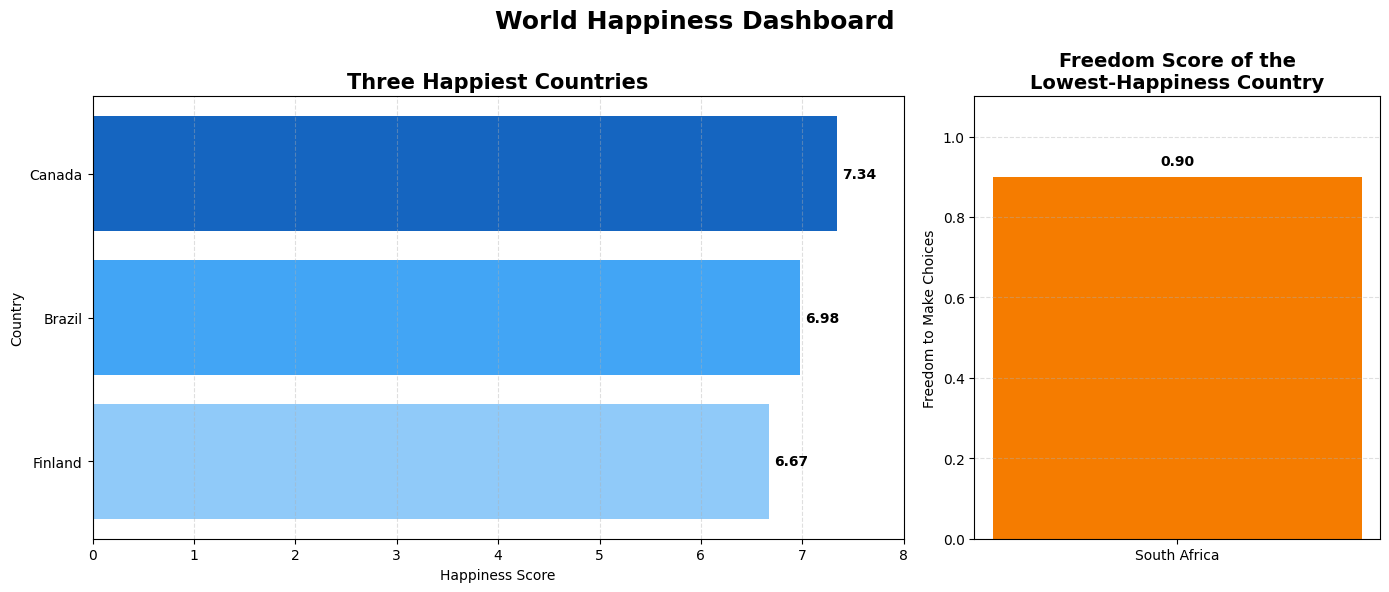

In [10]:
top_3_chart = top_3.sort_values(
    by="Happiness_Score",
    ascending=True
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    gridspec_kw={"width_ratios": [2, 1]}
)

bars = axes[0].barh(
    top_3_chart["Country"],
    top_3_chart["Happiness_Score"],
    color=["#90CAF9", "#42A5F5", "#1565C0"]
)

axes[0].set_title(
    "Three Happiest Countries",
    fontsize=15,
    fontweight="bold"
)
axes[0].set_xlabel("Happiness Score")
axes[0].set_ylabel("Country")
axes[0].set_xlim(0, 8)
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

for bar in bars:
    score = bar.get_width()

    axes[0].text(
        score + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.2f}",
        va="center",
        fontweight="bold"
    )

freedom_bar = axes[1].bar(
    [lowest_country_name],
    [lowest_freedom],
    color="#F57C00",
    width=0.5
)

axes[1].set_title(
    "Freedom Score of the\nLowest-Happiness Country",
    fontsize=14,
    fontweight="bold"
)
axes[1].set_ylabel("Freedom to Make Choices")
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].text(
    freedom_bar[0].get_x() + freedom_bar[0].get_width() / 2,
    lowest_freedom + 0.03,
    f"{lowest_freedom:.2f}",
    ha="center",
    fontweight="bold"
)

plt.suptitle(
    "World Happiness Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "matplotlib_happiness_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
fig = px.bar(
    top_3.sort_values("Happiness_Score"),
    x="Happiness_Score",
    y="Country",
    orientation="h",
    color="Happiness_Score",
    text="Happiness_Score",
    color_continuous_scale="Blues",
    title="Three Happiest Countries"
)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Happiness Score",
    yaxis_title="Country",
    xaxis_range=[0, 8],
    coloraxis_showscale=False,
    template="plotly_white",
    title_x=0.5
)

fig.show()

fig.write_html("plotly_happiness_chart.html")

In [12]:
plotly_dashboard = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Three Happiest Countries",
        f"Freedom Score: {lowest_country_name}"
    ),
    column_widths=[0.65, 0.35]
)

plotly_dashboard.add_trace(
    go.Bar(
        x=top_3["Country"],
        y=top_3["Happiness_Score"],
        name="Happiness Score",
        marker_color=["#1565C0", "#42A5F5", "#90CAF9"],
        text=top_3["Happiness_Score"],
        texttemplate="%{text:.2f}",
        textposition="outside"
    ),
    row=1,
    col=1
)

plotly_dashboard.add_trace(
    go.Bar(
        x=[lowest_country_name],
        y=[lowest_freedom],
        name="Freedom Score",
        marker_color="#F57C00",
        text=[lowest_freedom],
        texttemplate="%{text:.2f}",
        textposition="outside"
    ),
    row=1,
    col=2
)

plotly_dashboard.update_yaxes(
    title_text="Happiness Score",
    range=[0, 8],
    row=1,
    col=1
)

plotly_dashboard.update_yaxes(
    title_text="Freedom Score",
    range=[0, 1.1],
    row=1,
    col=2
)

plotly_dashboard.update_layout(
    title={
        "text": "World Happiness Dashboard",
        "x": 0.5
    },
    template="plotly_white",
    height=550,
    showlegend=False
)

plotly_dashboard.show()

plotly_dashboard.write_html("happiness_dashboard.html")

In [ ]:
## Approach and findings

The cleaned World Happiness dataset was loaded using Pandas and checked
for missing values and duplicate records. Each country occurs once in
the dataset, so the countries were ranked directly by their Happiness
Score without requiring aggregation.

The three happiest countries were Canada with 7.34, Brazil with 6.98,
and Finland with 6.67. South Africa recorded the lowest Happiness Score
of 3.53. Its Freedom to Make Choices score was 0.90.

Matplotlib was used to create a static dashboard suitable for inclusion
in a report. Plotly was used to create an interactive dashboard that
allows users to hover over the bars and inspect exact values.

In [ ]:
## Most appropriate chart

A bar chart is the most appropriate visualisation for this task because
the analysis compares numerical happiness scores across a small number
of categorical values—the country names. Bar lengths make differences
between countries easy to identify and compare.

A horizontal bar chart is especially useful when country names are long.
A pie chart would be less appropriate because happiness scores are not
parts of a whole. A line chart would also be unsuitable because the
countries do not represent a continuous time sequence.